# API Data Wrangling with Open-Meteo
#### Modified for Seattle and London

In this exercise, we will:

- Fetch historical weather data using the **Open-Meteo API**.
- Parse and clean the data using **pandas**.
- Perform exploratory data analysis.
- Visualize weather trends.

In [3]:
# Install required packages if not already installed
# !pip install requests pandas matplotlib --quiet

In [10]:
# Import Libraries
import requests
import pandas as pd
import matplotlib.pyplot as plt

# Optional: Configure matplotlib for inline display in Jupyter
%matplotlib inline

## Understand the Open-Meteo API

- **API Endpoint**: `https://archive-api.open-meteo.com/v1/archive`
- **Parameters**:
  - `latitude`: Latitude of the location.
  - `longitude`: Longitude of the location.
  - `start_date`: Start date of the data (YYYY-MM-DD).
  - `end_date`: End date of the data (YYYY-MM-DD).
  - `hourly`: Comma-separated list of variables (e.g., temperature, precipitation).
  - `timezone`: Timezone of the data.

**Documentation**: [Open-Meteo API Docs](https://open-meteo.com/en/docs)

In [12]:
# Step 1: Set Up Parameters

# Location coordinates for London
latitude = 51.5074
longitude = -0.1278

# Date range
start_date = '2022-01-01'
end_date = '2022-12-31'  # One year of data

# Variables to fetch
hourly_variables = ['precipitation', 'relativehumidity_2m', 'temperature_2m']


In [14]:
# Step 2: Make the API Request

base_url = 'https://archive-api.open-meteo.com/v1/archive'

params = {
    'latitude': latitude,
    'longitude': longitude,
    'start_date': start_date,
    'end_date': end_date,
    'hourly': ','.join(hourly_variables),
    'timezone': 'Europe/London'
}

response = requests.get(base_url, params=params)


In [16]:
# Check if the request was successful

if response.status_code == 200:
    print('Data fetched successfully!')
else:
    print(f'Failed to fetch data. Status code: {response.status_code}')


Data fetched successfully!


In [18]:
# Step 3: Load Data into pandas DataFrame

data = response.json()
hourly_data = data['hourly']

df = pd.DataFrame(hourly_data)
df.head()


,time,precipitation,relativehumidity_2m
0,2022-01-01T00:00,0.0,93
1,2022-01-01T01:00,0.0,93
2,2022-01-01T02:00,0.0,93
3,2022-01-01T03:00,0.0,92
4,2022-01-01T04:00,0.0,93


In [20]:
# Step 4: Data Cleaning

# Convert 'time' column to datetime
df['time'] = pd.to_datetime(df['time'])

# Set 'time' as the index
df.set_index('time', inplace=True)

# Check for missing values
df.isnull().sum()


precipitation          0
relativehumidity_2m    0
dtype: int64

In [22]:
# Handle missing values (if any)
df.ffill(inplace=True)  # Forward fill


In [24]:
# Step 5: Exploratory Data Analysis

# Summary Statistics
df.describe()

,precipitation,relativehumidity_2m
count,8760.000000,8760.000000
mean,0.075696,76.635160
std,0.404506,16.721898
min,0.000000,17.000000
25%,0.000000,65.000000
50%,0.000000,81.000000
75%,0.000000,90.000000
max,14.700000,100.000000


In [26]:
# Plot Temperature Over Time

#plt.figure(figsize=(14, 6))
#plt.plot(df.index, df['precipitation'], label='precipitation')
#plt.title('Precipitation Over Time in London')
#plt.xlabel('Date')
#plt.ylabel('Precipitation')
#plt.legend()
#plt.show()

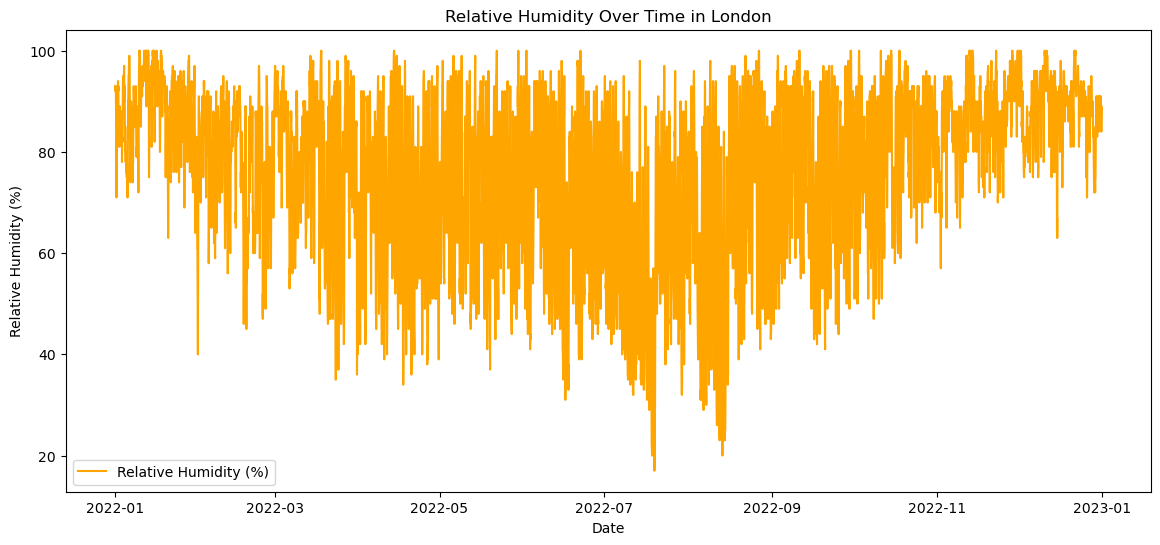

In [28]:
# Plot Relative Humidity Over Time

plt.figure(figsize=(14, 6))
plt.plot(df.index, df['relativehumidity_2m'], color='orange', label='Relative Humidity (%)')
plt.title('Relative Humidity Over Time in London')
plt.xlabel('Date')
plt.ylabel('Relative Humidity (%)')
plt.legend()
plt.show()


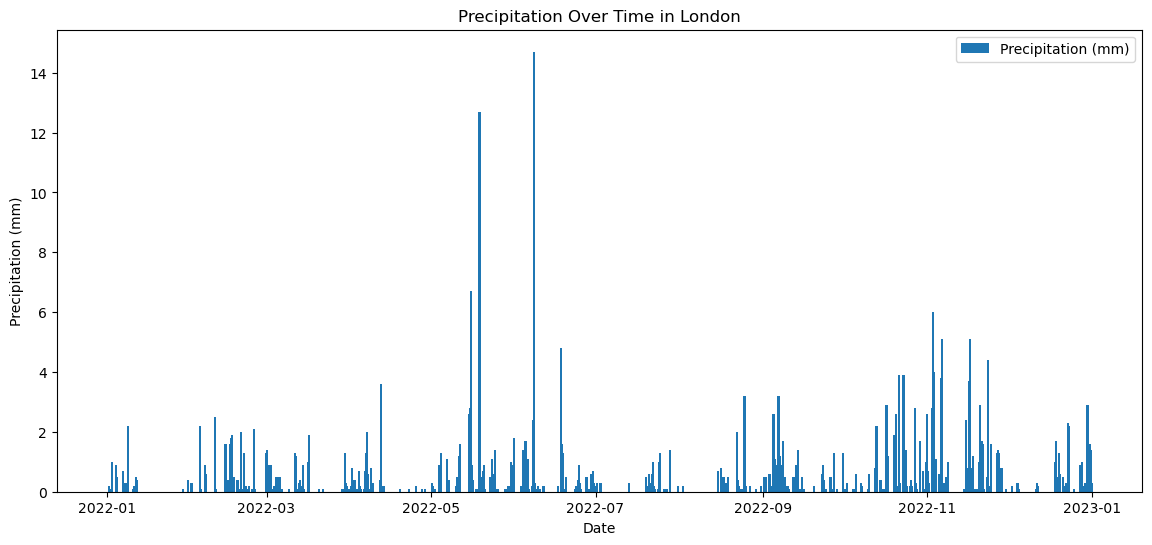

In [30]:
# Plot Precipitation Over Time

plt.figure(figsize=(14, 6))
plt.bar(df.index, df['precipitation'], label='Precipitation (mm)')
plt.title('Precipitation Over Time in London')
plt.xlabel('Date')
plt.ylabel('Precipitation (mm)')
plt.legend()
plt.show()


In [31]:
# Step 6: Correlation Analysis

# Calculate correlation between temperature and humidity
correlation = df['precipitation'].corr(df['relativehumidity_2m'])
print(f'Correlation between Temperature and Relative Humidity: {correlation:.2f}')


Correlation between Temperature and Relative Humidity: 0.10


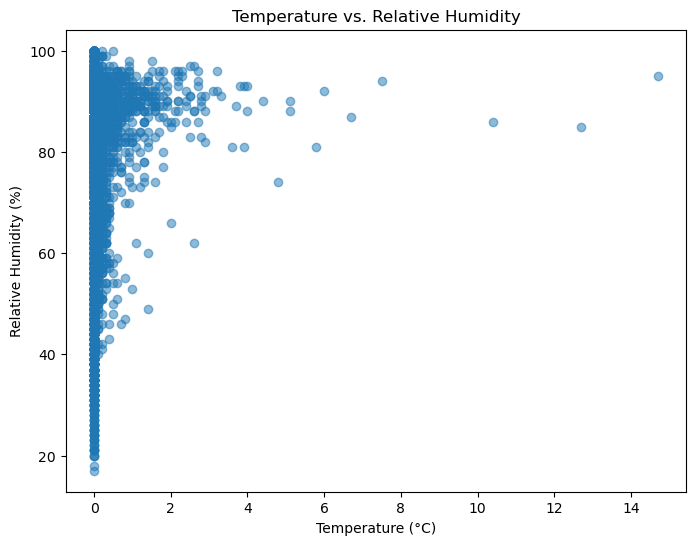

In [32]:
# Scatter Plot of Temperature vs. Relative Humidity

plt.figure(figsize=(8, 6))
plt.scatter(df['precipitation'], df['relativehumidity_2m'], alpha=0.5)
plt.title('Temperature vs. Relative Humidity')
plt.xlabel('Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.show()


In [33]:
# Step 7: Resample Data to Weekly Averages

daily_avg = df.resample('W').mean()
daily_avg.head()


,precipitation,relativehumidity_2m
time,,
2022-01-02,0.045833,86.458333
2022-01-09,0.076786,86.089286
2022-01-16,0.018452,94.696429
2022-01-23,0.000000,89.416667
2022-01-30,0.002381,86.476190


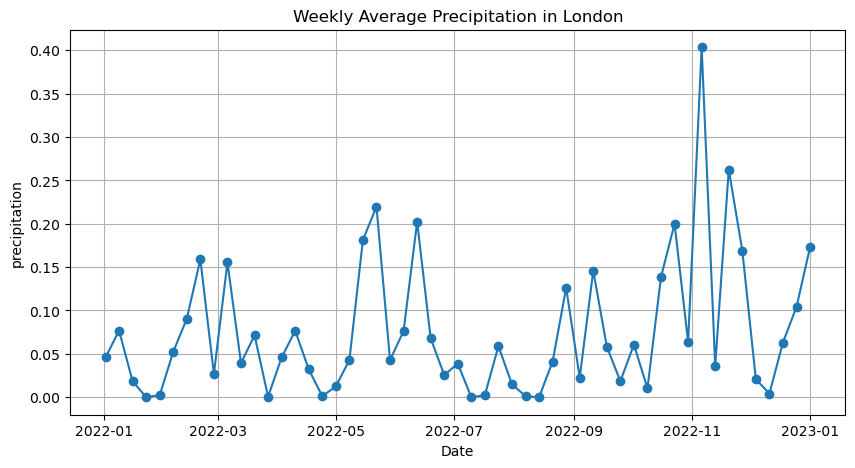

In [34]:
# Plot Daily Average Precip

plt.figure(figsize=(10, 5))
plt.plot(daily_avg.index, daily_avg['precipitation'], marker='o')
plt.title('Weekly Average Precipitation in London')
plt.xlabel('Date')
plt.ylabel('precipitation')
plt.grid(True)
plt.show()


In [40]:
# Step 8: Compare with Another Location (Seattle)

# Coordinates for Seattle
latitude_la = 47.6062
longitude_la = -122.3321

params_la = {
    'latitude': latitude_la,
    'longitude': longitude_la,
    'start_date': start_date,
    'end_date': end_date,
    'hourly': ','.join(hourly_variables),
    'timezone': 'America/Los_Angeles'
}

response_la = requests.get(base_url, params=params_la)

# Load and clean Los Angeles data
data_la = response_la.json()
hourly_data_la = data_la['hourly']
df_la = pd.DataFrame(hourly_data_la)

df_la['time'] = pd.to_datetime(df_la['time'])
df_la.set_index('time', inplace=True)
df_la.ffill(inplace=True)


In [42]:
# Resample Seattle Data to Weekly Averages

daily_avg_la = df_la.resample('W').mean()


In [44]:
# Combine DataFrames for Comparison

combined_temp = pd.DataFrame({
    'London': daily_avg['precipitation'],
    'Seattle': daily_avg_la['precipitation']
})


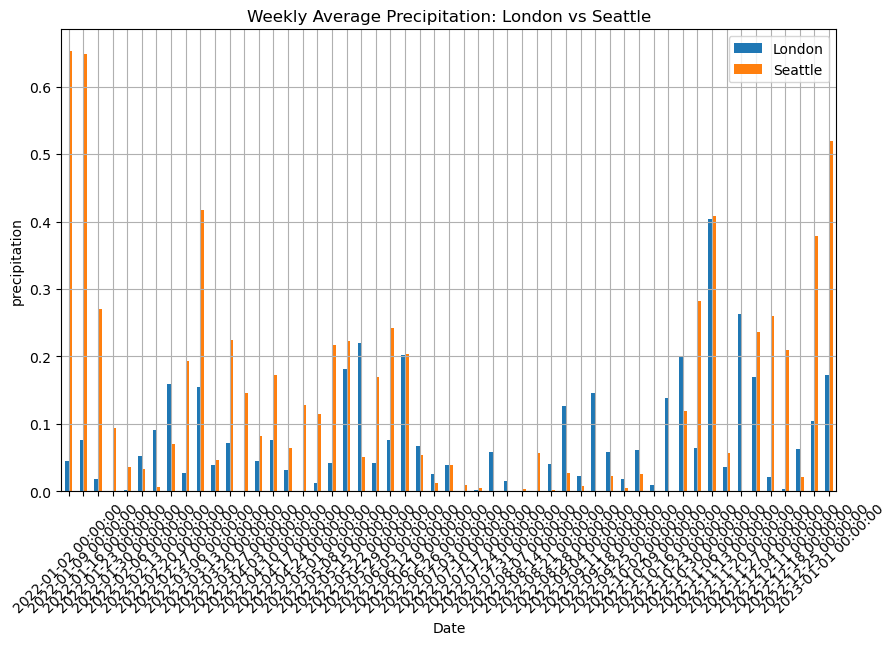

In [46]:
# Plot Comparison of Daily Average Temperature

combined_temp.plot(kind='bar', figsize=(10, 6))
plt.title('Weekly Average Precipitation: London vs Seattle')
plt.xlabel('Date')
plt.ylabel('precipitation')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


In [48]:
# Step 9: Advanced Analysis - Temperature Difference

# Calculate Temperature Difference
combined_temp['Humidity Difference'] = combined_temp['Seattle'] - combined_temp['London']
combined_temp


,London,Seattle,Humidity Difference
time,,,
2022-01-02,0.045833,0.652083,0.606250
2022-01-09,0.076786,0.647619,0.570833
2022-01-16,0.018452,0.270833,0.252381
2022-01-23,0.000000,0.093452,0.093452
2022-01-30,0.002381,0.036310,0.033929
2022-02-06,0.052381,0.033333,-0.019048
2022-02-13,0.090476,0.007143,-0.083333
2022-02-20,0.158929,0.070833,-0.088095
2022-02-27,0.026786,0.192857,0.166071


In [50]:
# Step 10: Save Data to CSV (Optional)

# Save New York data
# df.to_csv('new_york_weather.csv')

# Save Los Angeles data
#df_la.to_csv('los_angeles_weather.csv')


## Conclusion

In this exercise, we:

- Accessed and retrieved data from the **Open-Meteo API**.
- Cleaned and preprocessed JSON data using **pandas**.
- Performed exploratory data analysis and visualization.
- Compared weather patterns between **New York City** and **Los Angeles**.

---

**Next Steps**:

- **Extend the Date Range**: Analyze seasonal trends by fetching data over several months.
- **Fetch Additional Variables**: Include wind speed, atmospheric pressure, or other interesting variables.
- **Forecasting**: Use statistical methods or machine learning models to forecast future weather patterns.
- **Global Analysis**: Compare data from other global cities to gain broader insights.


## Exercises for Students

Now it's your turn! Below are some exercises to reinforce what you've learned. Try to complete them without looking at the solutions.

### Exercise: Compare Rainfall Between London and Seattle

- **Objective**: Compare the total weekly rainfall between London and Seattle over a full year.
- **Tasks**:
  1. **Fetch Data**: Retrieve hourly precipitation data for London and Seattle for the year 2022.
     - **London Coordinates**: Latitude `51.5074`, Longitude `-0.1278`
     - **Seattle Coordinates**: Latitude `47.6062`, Longitude `-122.3321`
  2. **Data Cleaning**: Convert the time columns to datetime objects and set them as the index. Handle any missing values.
  3. **Resample Data**: Resample the hourly data to weekly totals.
  4. **Visualization**: Plot the weekly total precipitation for both cities on the same graph.
  5. **Analysis**: Determine which city had more rainfall overall and identify any interesting patterns.

**Note**: Remember to handle any API limitations, such as data availability or rate limits, and to be mindful of the size of the data you're requesting.

### Tips:

- **API Parameters**: Make sure to adjust the parameters like `latitude`, `longitude`, `start_date`, `end_date`, `hourly`, and `timezone` as needed.
- **Error Handling**: Always check if your API requests are successful before proceeding.
- **Data Storage**: Consider saving your DataFrames to CSV files for future analysis.
- **Visualization**: Customize your plots with titles, labels, legends, and gridlines for better readability.

Happy coding!
